# 05. Incertidumbre de estimación

En el notebook 04 vimos que los pesos óptimos cambian mucho según el periodo usado para estimar. Aquí cuantifico por qué:

1. **Error de estimación de las medias:** cuánto se equivoca, como mínimo, una rentabilidad media estimada con 10 años de datos.
2. **Bootstrap de los pesos:** remuestreo los datos muchas veces y miro cuánto cambia la cartera de máximo Sharpe.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from src.portfolio import (error_estandar_medias, error_estandar_sharpe,
                               bootstrap_pesos_max_sharpe, resumen_pesos, medias_shrinkage)

precios = pd.read_csv("../data/precios.csv", index_col="Date", parse_dates=True)
rentabilidades = precios.pct_change().dropna()
rf_hist = pd.read_csv("../data/rf_hist.csv", index_col=0).squeeze("columns")["rf_hist"]

### Error de estimación de la rentabilidad media

Una rentabilidad media estimada con pocos años de datos es muy imprecisa. El error estándar de la media es aproximadamente la volatilidad anual dividida por la raíz de los años de datos. El intervalo del 95 % es la media ± 2 errores estándar.

In [2]:
print(f"Error estándar aproximado del Sharpe de cada activo: {error_estandar_sharpe(rentabilidades):.2f}")
error_estandar_medias(rentabilidades).round(3)

Error estándar aproximado del Sharpe de cada activo: 0.32


,Rentabilidad anual,Volatilidad anual,Error estándar,IC 95% inferior,IC 95% superior
AGG,0.021,0.054,0.017,-0.013,0.055
EEM,0.099,0.203,0.064,-0.030,0.228
EFA,0.096,0.172,0.055,-0.013,0.205
GLD,0.146,0.148,0.047,0.052,0.240
SPY,0.155,0.180,0.057,0.041,0.269
VNQ,0.073,0.208,0.066,-0.058,0.205


Solo GLD y SPY tienen un intervalo que no incluye el 0. Además, los intervalos de todos los activos se solapan mucho: con estos datos no se puede afirmar que GLD o SPY rindan de verdad más que EEM o EFA. El error estándar del Sharpe (≈ 0,32) también es grande.

### Comprobación del error estándar del Sharpe

La fórmula 1/√años es una aproximación. La compruebo con la cartera de máximo Sharpe de toda la muestra (notebook 03) de tres formas:

- **Lo (2002)** aplicada a los rendimientos diarios y pasada a anual: $\sqrt{(1 + SR^2/2)/n}$, con el Sharpe diario y $n$ días.
- **Mertens (2002)**, que añade la asimetría y la curtosis (colas gruesas).
- **Bootstrap por bloques**, que no supone normalidad ni independencia entre días.

In [3]:
from src.portfolio import cartera_max_sharpe, error_estandar_sharpe_lo, error_estandar_sharpe_bootstrap

w_ms = cartera_max_sharpe(rentabilidades.cov().values * 252, rentabilidades.mean().values * 252, rf_hist)
rend_ms = rentabilidades.values @ w_ms          # rendimientos diarios de la cartera de máximo Sharpe

se = error_estandar_sharpe_lo(rend_ms, rf_hist)
se["Error estándar (1/raíz(años))"] = error_estandar_sharpe(rentabilidades)
for b in [1, 21, 63]:
    se[f"Error estándar (bootstrap, bloque {b})"] = error_estandar_sharpe_bootstrap(rend_ms, rf_hist, bloque=b)
se.round(3)

Sharpe anual                             1.088
Error estándar (Lo)                      0.317
Error estándar (Mertens)                 0.320
Error estándar (1/raíz(años))            0.317
Error estándar (bootstrap, bloque 1)     0.319
Error estándar (bootstrap, bloque 21)    0.317
Error estándar (bootstrap, bloque 63)    0.293
dtype: float64

**Resultado.** Todas las formas dan prácticamente lo mismo: un error de ≈ 0,32 para un Sharpe de 1,09. Con datos diarios, el término $SR^2/2$ de Lo se aplica al Sharpe diario (≈ 0,07), que es muy pequeño, así que 1/√años es una buena aproximación.

Ojo: aplicar la fórmula con el Sharpe anual y los años de datos, $\sqrt{(1 + 1{,}09^2/2)/10} ≈ 0{,}40$, mezcla frecuencias y sobrestima el error. Las colas gruesas casi no lo cambian (Mertens: 0,320), y el bootstrap, que tampoco supone independencia entre días, da entre 0,29 y 0,32. En cualquier caso el error es grande: el Sharpe de 1,09 es compatible con valores entre ≈ 0,45 y ≈ 1,7 (± 2 errores).

Bootstrap de los pesos óptimos

Remuestreo los datos 1000 veces, pegando bloques de 21 días (1 mes) elegidos al azar (así se conserva la dependencia entre días consecutivos) hasta llegar a una muestra de 10 años, y en cada remuestreo recalculo la cartera de máximo Sharpe. Si los pesos cambian mucho de un remuestreo a otro, la "cartera óptima" es en realidad un rango.

Este bootstrap solo mide el **error de muestreo**: remuestrea los mismos diez años. No captura un cambio de régimen como el de los tipos de interés.

In [4]:
pesos_boot = bootstrap_pesos_max_sharpe(rentabilidades, rf_hist, n_rep=1000, z=1.0)
resumen_pesos(pesos_boot).round(3)

,Peso medio,Percentil 5,Percentil 95
AGG,0.015,0.000,0.123
EEM,0.004,0.000,0.000
EFA,0.003,0.000,0.000
GLD,0.558,0.300,0.827
SPY,0.418,0.162,0.669
VNQ,0.002,0.000,0.000


- GLD y SPY concentran casi toda la cartera, pero con rangos muy anchos: GLD entre 0,30 y 0,83 y SPY entre 0,16 y 0,67.
- EEM, EFA y VNQ tienen el percentil 95 en 0: en más del 95 % de los remuestreos su peso es exactamente 0.
- AGG vale 0 en la gran mayoría de los remuestreos y entra pocas veces con pesos altos (su percentil 95 es 0,123), por eso su media es pequeña pero no nula.

### Distribución de los pesos (KDE) y Box-Plot

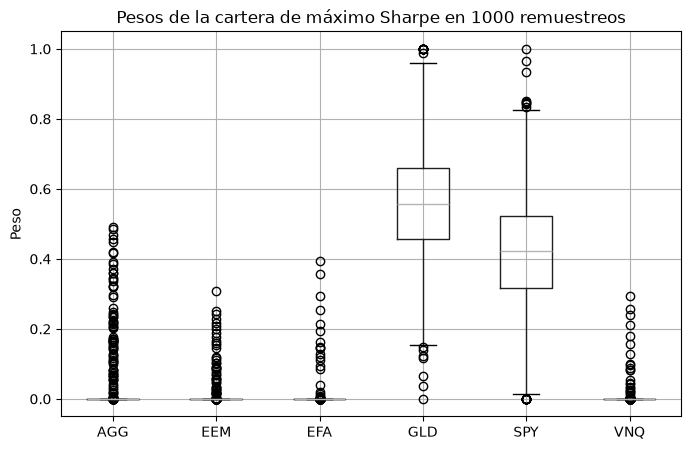

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
pesos_boot.boxplot(ax=ax)
ax.set_title("Pesos de la cartera de máximo Sharpe en 1000 remuestreos")
ax.set_ylabel("Peso")
plt.show()

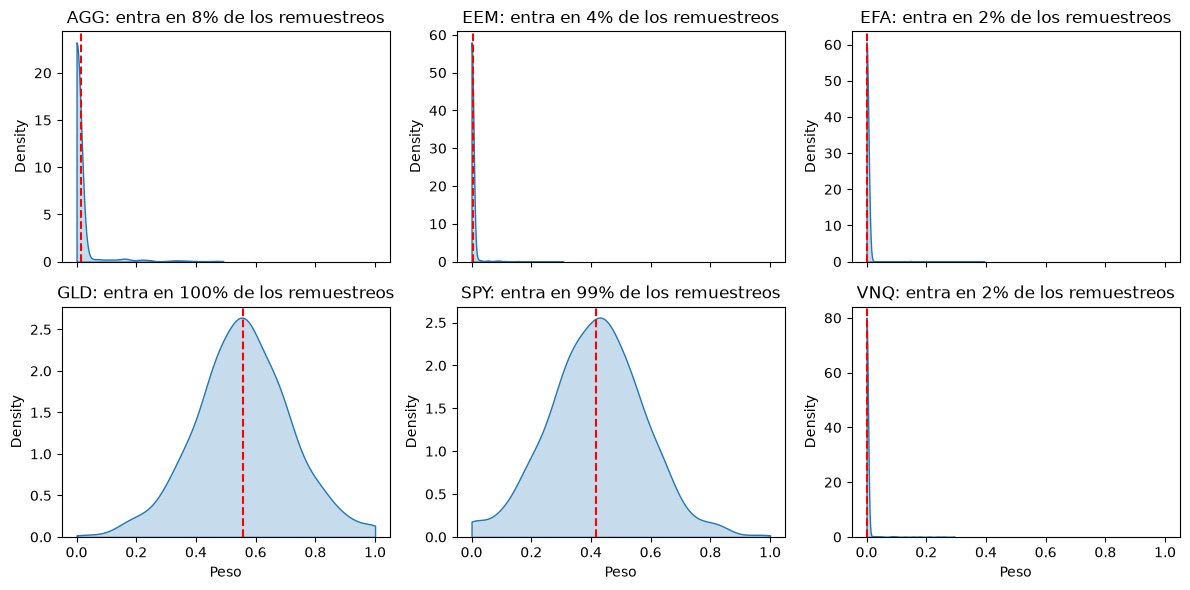

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
for ax, activo in zip(axes.ravel(), pesos_boot.columns):
    sns.kdeplot(pesos_boot[activo], ax=ax, fill=True, cut=0)
    ax.axvline(pesos_boot[activo].mean(), color="red", linestyle="--")
    veces = (pesos_boot[activo] > 0.01).mean()
    ax.set_title(f"{activo}: entra en {veces:.0%} de los remuestreos")
    ax.set_xlabel("Peso")
plt.tight_layout()

Cada curva muestra cómo se reparten los 1000 pesos de un activo. Un pico alto y estrecho significa que el peso casi siempre es el mismo; una curva ancha, que los remuestreos no se ponen de acuerdo. La línea roja es el peso medio y el título indica en qué porcentaje de los remuestreos el activo recibe algún peso.

AGG, EEM, EFA y VNQ tienen un pico en 0: casi nunca entran. GLD y SPY tienen curvas anchas: su peso depende mucho de la muestra.

<Axes: xlabel='GLD', ylabel='SPY'>

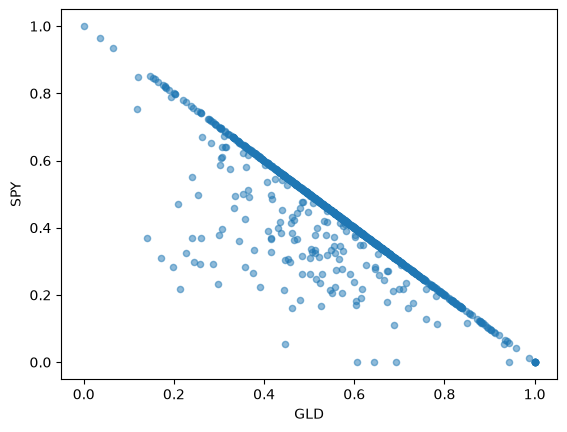

In [7]:
pesos_boot.plot.scatter(x="GLD", y="SPY", alpha=0.5)

Cada punto es un remuestreo. Los puntos sobre la diagonal son carteras formadas solo por GLD y SPY (la suma de pesos es 1). El optimizador siempre elige entre oro y bolsa, pero la proporción es inestable.

### Sensibilidad a la longitud de bloque

He usado bloques de 21 días, pero la elección es arbitraria. Repito el bootstrap con bloques de 5 a 63 días y miro el intervalo P5-P95 de GLD y SPY.

In [8]:
filas = {}
for b in [5, 10, 21, 42, 63]:
    p = bootstrap_pesos_max_sharpe(rentabilidades, rf_hist, n_rep=1000, bloque=b)
    filas[f"Bloque {b}"] = {"GLD P5": p["GLD"].quantile(0.05), "GLD P95": p["GLD"].quantile(0.95),
                            "SPY P5": p["SPY"].quantile(0.05), "SPY P95": p["SPY"].quantile(0.95)}
pd.DataFrame(filas).T.round(2)

,GLD P5,GLD P95,SPY P5,SPY P95
Bloque 5,0.31,0.82,0.13,0.67
Bloque 10,0.31,0.81,0.17,0.66
Bloque 21,0.30,0.83,0.16,0.67
Bloque 42,0.24,0.83,0.15,0.74
Bloque 63,0.24,0.81,0.16,0.74


**Resultado.** Con bloques de 5 a 21 días los intervalos apenas cambian (GLD entre ≈ 0,30 y ≈ 0,83; SPY entre ≈ 0,15 y ≈ 0,67). Con bloques de 42 y 63 días se ensanchan un poco (GLD desde 0,24; SPY hasta 0,74), porque conservan más dependencia entre días y hay menos bloques distintos para combinar. La conclusión no depende del tamaño de bloque: con cualquiera de ellos los pesos son muy inestables.

### Cartera remuestreada (Michaud)

La media de los pesos del bootstrap es, en esencia, la cartera remuestreada (*resampled efficiency*) de Michaud (1998): en lugar de fiarse de una sola optimización, promedia las de muchas muestras posibles. La comparo con la de máximo Sharpe original, con las medias y covarianzas de toda la muestra.

In [9]:
from src.portfolio import ratio_sharpe

mu_total = rentabilidades.mean().values * 252
cov_total = rentabilidades.cov().values * 252
w_remuestreada = pesos_boot.mean().values

comparacion_michaud = pd.DataFrame({"Máx. Sharpe": w_ms, "Remuestreada": w_remuestreada},
                                   index=rentabilidades.columns)
comparacion_michaud.loc["Sharpe (muestra completa)"] = [ratio_sharpe(w_ms, cov_total, mu_total, rf_hist),
                                                       ratio_sharpe(w_remuestreada, cov_total, mu_total, rf_hist)]
comparacion_michaud.round(3)

,Máx. Sharpe,Remuestreada
AGG,0.000,0.015
EEM,0.000,0.004
EFA,0.000,0.003
GLD,0.583,0.558
SPY,0.417,0.418
VNQ,0.000,0.002
Sharpe (muestra completa),1.088,1.080


**Resultado.** La cartera remuestreada mantiene la misma estructura (55,8 % GLD, 41,8 % SPY y pequeñas posiciones en el resto) y tiene un Sharpe en la muestra de 1,08, casi igual que el 1,09 de la original. En este universo, remuestrear apenas cambia la cartera media; lo que aporta el bootstrap es la medida de su incertidumbre.

### Shrinkage de las rentabilidades medias

Las medias históricas son muy imprecisas con solo diez años de datos, y el optimizador las toma al pie de la letra. Para suavizarlas, mezclo la media de cada activo con un valor de referencia (el prior): la rentabilidad que tendría si todos los activos ofrecieran el mismo Sharpe, igual a la media de los Sharpe de los seis.

prior = rf + Sharpe medio × volatilidad del activo

media ajustada = Z · media del activo + (1 − Z) · prior

Equivale a encoger el Sharpe de cada activo hacia el Sharpe medio. Z es la credibilidad que doy a los datos: Z = 1 usa solo la media histórica y Z = 0 usa solo el prior.

In [10]:
medias_orig = rentabilidades.mean() * 252
medias_aj = medias_shrinkage(rentabilidades, z=0.5, rf=rf_hist)
pd.DataFrame({"Media original": medias_orig, "Media ajustada": medias_aj}).round(3)

,Media original,Media ajustada
AGG,0.021,0.033
EEM,0.099,0.105
EFA,0.096,0.096
GLD,0.146,0.116
SPY,0.155,0.128
VNQ,0.073,0.093


Las medias de GLD y SPY bajan (GLD de 0,146 a 0,116; SPY de 0,155 a 0,128) y las de AGG, EEM y VNQ suben (AGG de 0,021 a 0,033; VNQ de 0,073 a 0,093). EFA casi no cambia. Las diferencias entre activos se reducen, pero GLD y SPY siguen siendo los de mayor rentabilidad esperada.

### Bootstrap con shrinkage (Z = 0,5)

Repito el bootstrap con las medias ajustadas al 50 % hacia el prior. Comparo con el caso sin ajuste (Z = 1) el peso medio y el ancho del intervalo entre los percentiles 5 y 95, que mide la estabilidad de cada peso: cuanto menor, más estable.

In [11]:
pesos_z05 = bootstrap_pesos_max_sharpe(rentabilidades, rf_hist, n_rep=1000, z=0.5)

comparacion = pd.DataFrame({
    "Peso medio (Z=1)": pesos_boot.mean(),
    "Peso medio (Z=0,5)": pesos_z05.mean(),
    "Ancho P5-P95 (Z=1)": pesos_boot.quantile(0.95) - pesos_boot.quantile(0.05),
    "Ancho P5-P95 (Z=0,5)": pesos_z05.quantile(0.95) - pesos_z05.quantile(0.05),
})
comparacion.round(3)

,Peso medio (Z=1),"Peso medio (Z=0,5)",Ancho P5-P95 (Z=1),"Ancho P5-P95 (Z=0,5)"
AGG,0.015,0.073,0.123,0.354
EEM,0.004,0.006,0.000,0.040
EFA,0.003,0.002,0.000,0.000
GLD,0.558,0.525,0.527,0.464
SPY,0.418,0.390,0.508,0.381
VNQ,0.002,0.004,0.000,0.014


Con Z = 0,5, el ancho P5-P95 de SPY baja un 25 % (de 0,508 a 0,381) y el de GLD solo un 12 % (de 0,527 a 0,464). El peso medio de AGG sube de 0,015 a 0,073, y su ancho también aumenta (de 0,123 a 0,354): ahora entra en más remuestreos, lo que no indica menos estabilidad. GLD y SPY siguen sumando el 92 % de la cartera.

### Barrido de Z

Repito el bootstrap con Z = 0, 0,25, 0,5, 0,75 y 1 para ver cómo cambian los pesos medios y su dispersión al dar más o menos credibilidad a los datos.

,AGG,EEM,EFA,GLD,SPY,VNQ
Z,,,,,,
0.00,0.518,0.065,0.022,0.210,0.144,0.042
0.25,0.209,0.010,0.002,0.437,0.336,0.006
0.50,0.073,0.006,0.002,0.525,0.390,0.004
0.75,0.029,0.005,0.003,0.551,0.410,0.003
1.00,0.015,0.004,0.003,0.558,0.418,0.002


,AGG,EEM,EFA,GLD,SPY,VNQ
Z,,,,,,
0.00,0.075,0.050,0.036,0.063,0.060,0.046
0.25,0.463,0.061,0.000,0.452,0.314,0.043
0.50,0.354,0.040,0.000,0.464,0.381,0.014
0.75,0.241,0.014,0.000,0.496,0.451,0.000
1.00,0.123,0.000,0.000,0.527,0.508,0.000


<Axes: title={'center': 'Peso medio de cada activo según Z'}, xlabel='Z'>

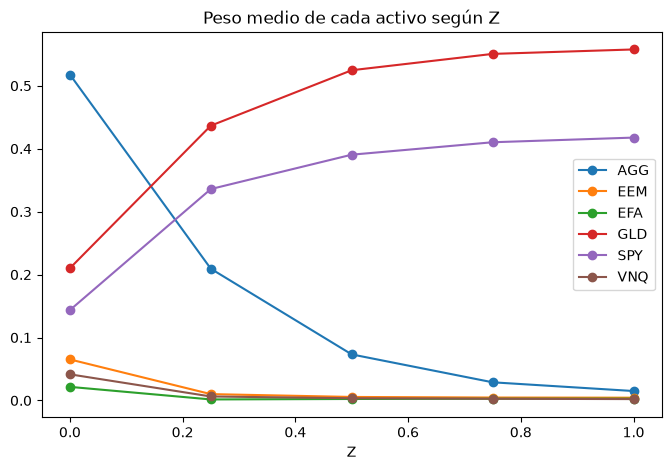

In [12]:
zs = [0, 0.25, 0.5, 0.75, 1]
resultados = {z: bootstrap_pesos_max_sharpe(rentabilidades, rf_hist, n_rep=1000, z=z) for z in zs}

medios = pd.DataFrame({z: p.mean() for z, p in resultados.items()}).T
anchos = pd.DataFrame({z: p.quantile(0.95) - p.quantile(0.05) for z, p in resultados.items()}).T
medios.index.name = anchos.index.name = "Z"

display(medios.round(3))
display(anchos.round(3))
medios.plot(marker="o", figsize=(8, 5), title="Peso medio de cada activo según Z")

### Resultado del barrido de Z

Con Z = 0 la cartera se apoya en AGG (52 %), el activo más tranquilo y el que más diversifica; GLD y SPY suman solo un 35 %. Los pesos son muy estables (ancho P5-P95 entre 0,04 y 0,08) porque no dependen de las medias de los datos, solo de la covarianza.

Al subir Z, AGG cede su peso a GLD y SPY, que ya suman el 77 % con Z = 0,25 y el 98 % con Z = 1. La mayor incertidumbre está en Z = 0,25 (el ancho de AGG llega a 0,46): el optimizador duda entre una cartera diversificada y una de oro y bolsa.

Un peso estable no implica una cartera mejor, y el prior de igual Sharpe es una suposición fuerte. Para elegir Z hace falta evaluar las carteras fuera de la muestra.